# ColabFold Local Notebook

This notebook mirrors the ColabFold/AlphaFold2 workflow for local use: MSA and optional PDB100 template hits are queried from `https://api.colabfold.com`, while AlphaFold inference runs in the local `colabfold` conda environment on local GPU hardware.

It does not require local UniRef, BFD, MGnify, PDB70, PDB100, or MMseqs databases. AlphaFold model parameters are downloaded locally on demand because inference runs on this machine.

## GPU selection

Edit `GPU_IDS` in the first code cell before running any other cell. Leave it empty to use all GPUs visible to Jupyter, set it to `"6"` to use physical GPU 6, or `"4,5"` to use physical GPUs 4 and 5.

GPU selection works by setting `CUDA_VISIBLE_DEVICES` before the first `import jax`. If JAX has already been imported, restart the kernel, set `GPU_IDS`, and run from the top. JAX renumbers filtered GPUs, so physical GPU 6 will appear as `CudaDevice(id=0)` when it is the only visible GPU.


In [6]:
# GPU and environment setup
# Set before importing jax. Examples: "6" for one physical GPU, "4,5" for two GPUs, "" for all GPUs visible to Jupyter.
GPU_IDS = "4,5,6,7"

import os
import shutil
from pathlib import Path

HOST_URL = "https://api.colabfold.com"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
if GPU_IDS.strip():
    os.environ["CUDA_VISIBLE_DEVICES"] = GPU_IDS.strip()

import jax
import colabfold

print("ColabFold import: OK")
print("Remote MSA server:", HOST_URL)
# print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES", "<not set>"))
# print("JAX devices:", jax.devices())
# for tool in ["colabfold_batch", "mmseqs", "hhblits", "hhsearch", "kalign"]:
#     print(f"{tool}:", shutil.which(tool) or "not found")


ColabFold import: OK
Remote MSA server: https://api.colabfold.com


In [12]:
# Local web-like controls. Change values here, then run the next cells.
import ipywidgets as widgets
from IPython.display import display

sequence = widgets.Textarea(
    value="PIAQIHILEGRSDEQKETLIREVSEAISRSLDAPLTSVRVIITEMAKGHFGIGGELASK",
    description="Sequence",
    layout=widgets.Layout(width="900px", height="120px"),
)
jobname = widgets.Text(value="test", description="Job name", layout=widgets.Layout(width="420px"))
output_dir = widgets.Text(value="outputs/local_colabfold", description="Output dir", layout=widgets.Layout(width="520px"))

msa_mode = widgets.Dropdown(
    options=["mmseqs2_uniref_env", "mmseqs2_uniref", "single_sequence", "custom"],
    value="mmseqs2_uniref_env",
    description="MSA mode",
)
pair_mode = widgets.Dropdown(
    options=["unpaired_paired", "paired", "unpaired"],
    value="unpaired_paired",
    description="Pair mode",
)
template_mode = widgets.Dropdown(
    options=["none", "pdb100", "custom"],
    value="none",
    description="Templates",
)
custom_msa_path = widgets.Text(value="", description="Custom MSA", layout=widgets.Layout(width="700px"))
custom_template_path = widgets.Text(value="", description="Custom tpl", layout=widgets.Layout(width="700px"))

model_type = widgets.Dropdown(
    options=["auto", "alphafold2_ptm", "alphafold2_multimer_v3", "alphafold2_multimer_v2", "alphafold2_multimer_v1", "alphafold2", "deepfold_v1"],
    value="auto",
    description="Model",
)
num_recycles = widgets.Dropdown(options=["auto", "0", "1", "3", "6", "12", "24", "48"], value="3", description="Recycles")
num_relax = widgets.Dropdown(options=[0, 1, 5], value=0, description="Relax")
relax_max_iterations = widgets.Dropdown(options=[0, 200, 2000], value=200, description="Relax iter")
num_seeds = widgets.Dropdown(options=[1, 2, 4, 8, 16], value=1, description="Seeds")
use_dropout = widgets.Checkbox(value=False, description="Use dropout")
max_msa = widgets.Dropdown(options=["auto", "512:1024", "256:512", "64:128", "32:64", "16:32"], value="auto", description="Max MSA")
pairing_strategy = widgets.Dropdown(options=["greedy", "complete"], value="greedy", description="Pairing")
save_all = widgets.Checkbox(value=False, description="Save all")
save_recycles = widgets.Checkbox(value=False, description="Save recycles")
zip_results = widgets.Checkbox(value=True, description="Zip results")
display_images = widgets.Checkbox(value=True, description="Display plots")

display(widgets.VBox([
    widgets.HTML("<b>Input</b>"), sequence, jobname, output_dir,
    widgets.HTML("<b>MSA and templates</b>"), widgets.HBox([msa_mode, pair_mode, template_mode]), custom_msa_path, custom_template_path,
    widgets.HTML("<b>Prediction</b>"), widgets.HBox([model_type, num_recycles, num_relax, relax_max_iterations]), widgets.HBox([num_seeds, use_dropout, max_msa, pairing_strategy]),
    widgets.HTML("<b>Output</b>"), widgets.HBox([save_all, save_recycles, zip_results, display_images]),
]))

In [23]:
# Prepare query files from the controls above.
import hashlib
import os
import re
import shutil
from pathlib import Path

def _clean_sequence(raw):
    return "".join(raw.split())

def _job_name(base, query):
    cleaned = re.sub(r"\W+", "", "".join(base.split())) or "colabfold"
    digest = hashlib.sha1(query.encode()).hexdigest()[:5]
    return f"{cleaned}_{digest}"

query_sequence = _clean_sequence(sequence.value)
if not query_sequence:
    raise ValueError("Sequence is empty.")

run_root = Path(output_dir.value).expanduser().resolve()
run_root.mkdir(parents=True, exist_ok=True)
job_name = _job_name(jobname.value, query_sequence)
job_dir = run_root / job_name
suffix = 0
while job_dir.exists():
    suffix += 1
    job_dir = run_root / f"{job_name}_{suffix}"
job_dir.mkdir(parents=True)
job_name = job_dir.name

queries_path = job_dir / f"{job_name}.csv"
a3m_file = job_dir / f"{job_name}.a3m"
selected_msa_mode = msa_mode.value

if selected_msa_mode == "custom":
    source_msa = Path(custom_msa_path.value).expanduser()
    if not source_msa.is_file():
        raise FileNotFoundError(f"Custom MSA file not found: {source_msa}")
    a3m_file = job_dir / f"{job_name}.custom.a3m"
    shutil.copy2(source_msa, a3m_file)
    queries_path = a3m_file
elif selected_msa_mode == "single_sequence":
    a3m_file = job_dir / f"{job_name}.single_sequence.a3m"
    a3m_file.write_text(f">{job_name}\n{query_sequence}\n")
    queries_path = a3m_file
else:
    queries_path.write_text(f"id,sequence\n{job_name},{query_sequence}\n")

selected_template_mode = template_mode.value
use_templates = selected_template_mode != "none"
resolved_custom_template_path = None
if selected_template_mode == "custom":
    resolved_custom_template_path = Path(custom_template_path.value).expanduser().resolve()
    if not resolved_custom_template_path.is_dir():
        raise FileNotFoundError(f"Custom template directory not found: {resolved_custom_template_path}")

print("Job:", job_name)
print("Sequence length:", len(query_sequence.replace(":", "")))
print("Run directory:", job_dir)
print("Query input:", queries_path)
print("MSA mode:", selected_msa_mode)
print("Template mode:", selected_template_mode)
print("Remote MSA server:", HOST_URL)

Job: TREX1_top_13_8f32d
Sequence length: 307
Run directory: /export/data/sfan/ColabFold/outputs/TREX1/TREX1_top_13_8f32d
Query input: /export/data/sfan/ColabFold/outputs/TREX1/TREX1_top_13_8f32d/TREX1_top_13_8f32d.csv
MSA mode: mmseqs2_uniref_env
Template mode: none
Remote MSA server: https://api.colabfold.com


Queries: 1
Complex input: True
Model type: alphafold2_multimer_v3
MSA mode: mmseqs2_uniref_env
Host URL: https://api.colabfold.com
Downloading/checking AlphaFold parameters if needed...
2026-05-08 01:24:10,625 Running on GPU
2026-05-08 01:24:10,631 Found 5 citations for tools or databases
2026-05-08 01:24:10,631 Query 1/1: TREX1_top_13_8f32d (length 307)


SUBMIT:   0%|          | 0/300 [elapsed: 00:00 remaining: ?]

COMPLETE: 100%|██████████| 300/300 [elapsed: 00:01 remaining: 00:00]


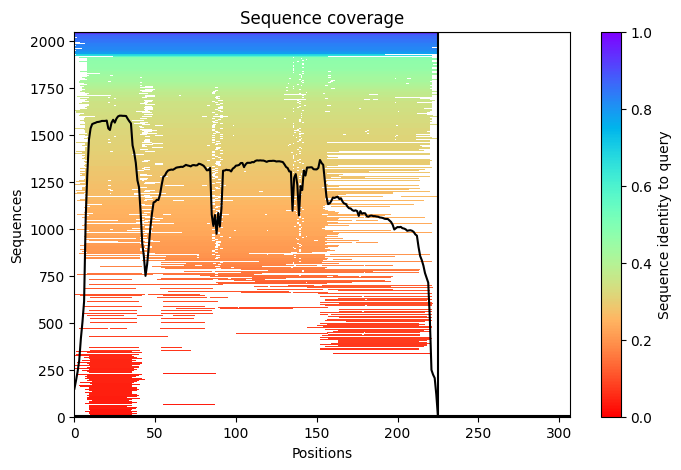

2026-05-08 01:24:16,424 Setting max_seq=508, max_extra_seq=1542
2026-05-08 01:25:34,382 alphafold2_multimer_v3_model_1_seed_000 recycle=0 pLDDT=77.5 pTM=0.787 ipTM=0.458
2026-05-08 01:26:47,110 alphafold2_multimer_v3_model_1_seed_000 recycle=1 pLDDT=87.9 pTM=0.888 ipTM=0.801 tol=1.73
2026-05-08 01:26:51,691 alphafold2_multimer_v3_model_1_seed_000 recycle=2 pLDDT=89.9 pTM=0.894 ipTM=0.817 tol=0.473
2026-05-08 01:26:51,692 alphafold2_multimer_v3_model_1_seed_000 took 151.2s (2 recycles)


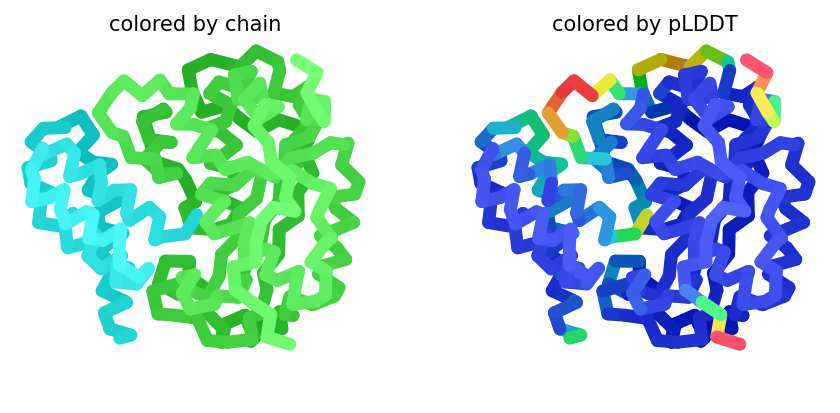

2026-05-08 01:26:56,533 alphafold2_multimer_v3_model_2_seed_000 recycle=0 pLDDT=76.8 pTM=0.773 ipTM=0.406
2026-05-08 01:27:01,174 alphafold2_multimer_v3_model_2_seed_000 recycle=1 pLDDT=80.2 pTM=0.795 ipTM=0.463 tol=4.67
2026-05-08 01:27:05,738 alphafold2_multimer_v3_model_2_seed_000 recycle=2 pLDDT=86.4 pTM=0.844 ipTM=0.649 tol=0.881
2026-05-08 01:27:10,335 alphafold2_multimer_v3_model_2_seed_000 recycle=3 pLDDT=85.8 pTM=0.845 ipTM=0.646 tol=0.399
2026-05-08 01:27:10,336 alphafold2_multimer_v3_model_2_seed_000 took 18.4s (3 recycles)


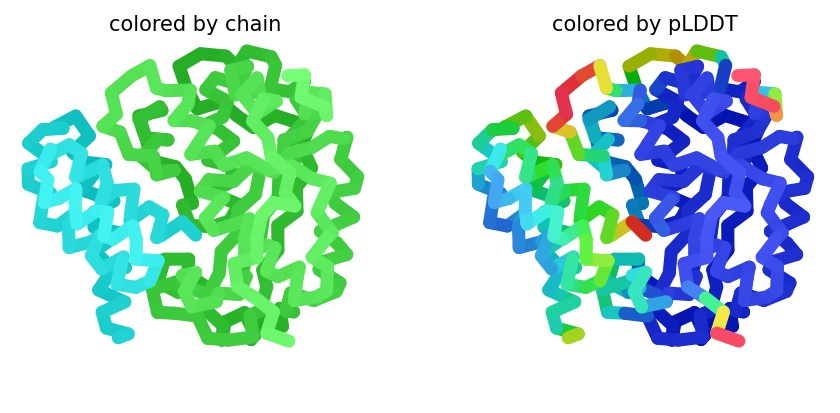

2026-05-08 01:27:15,122 alphafold2_multimer_v3_model_3_seed_000 recycle=0 pLDDT=74.6 pTM=0.745 ipTM=0.297
2026-05-08 01:27:19,612 alphafold2_multimer_v3_model_3_seed_000 recycle=1 pLDDT=81.8 pTM=0.799 ipTM=0.461 tol=1.83
2026-05-08 01:27:24,197 alphafold2_multimer_v3_model_3_seed_000 recycle=2 pLDDT=87 pTM=0.842 ipTM=0.612 tol=1.3
2026-05-08 01:27:28,723 alphafold2_multimer_v3_model_3_seed_000 recycle=3 pLDDT=86.3 pTM=0.827 ipTM=0.559 tol=0.434
2026-05-08 01:27:28,724 alphafold2_multimer_v3_model_3_seed_000 took 18.1s (3 recycles)


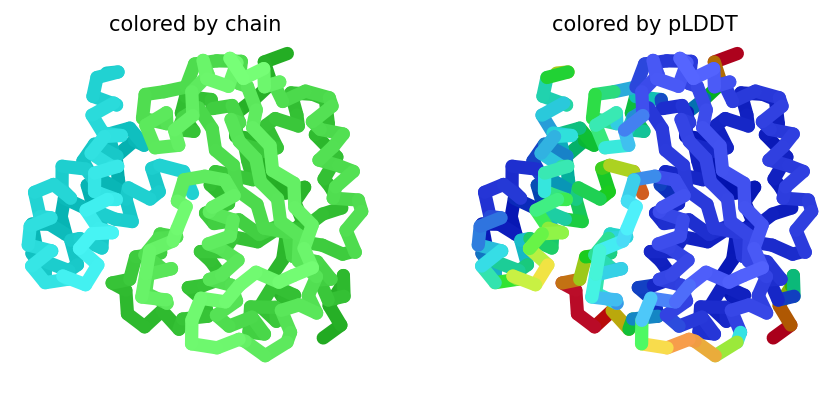

2026-05-08 01:27:33,611 alphafold2_multimer_v3_model_4_seed_000 recycle=0 pLDDT=79.4 pTM=0.824 ipTM=0.578
2026-05-08 01:27:38,188 alphafold2_multimer_v3_model_4_seed_000 recycle=1 pLDDT=79.4 pTM=0.8 ipTM=0.487 tol=1.02
2026-05-08 01:27:42,730 alphafold2_multimer_v3_model_4_seed_000 recycle=2 pLDDT=80.9 pTM=0.801 ipTM=0.48 tol=0.917
2026-05-08 01:27:47,336 alphafold2_multimer_v3_model_4_seed_000 recycle=3 pLDDT=88.4 pTM=0.881 ipTM=0.761 tol=1.1
2026-05-08 01:27:51,913 alphafold2_multimer_v3_model_4_seed_000 recycle=4 pLDDT=90 pTM=0.893 ipTM=0.805 tol=0.27
2026-05-08 01:27:51,914 alphafold2_multimer_v3_model_4_seed_000 took 23.0s (4 recycles)


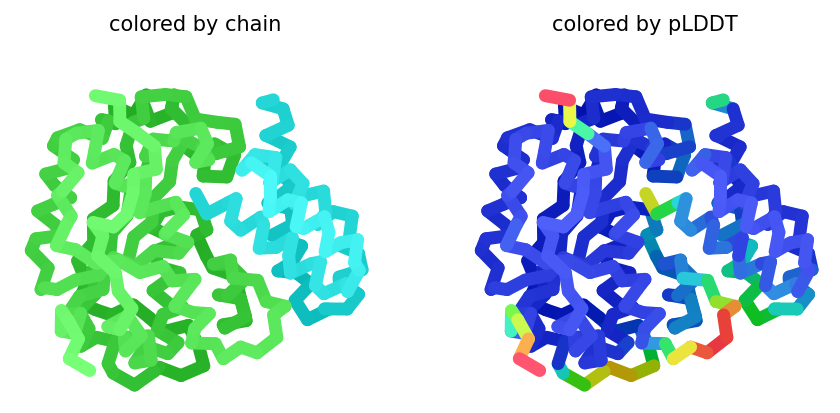

2026-05-08 01:27:56,751 alphafold2_multimer_v3_model_5_seed_000 recycle=0 pLDDT=74.6 pTM=0.753 ipTM=0.322
2026-05-08 01:28:01,350 alphafold2_multimer_v3_model_5_seed_000 recycle=1 pLDDT=76.8 pTM=0.771 ipTM=0.368 tol=1.53
2026-05-08 01:28:05,885 alphafold2_multimer_v3_model_5_seed_000 recycle=2 pLDDT=77.8 pTM=0.768 ipTM=0.357 tol=0.774
2026-05-08 01:28:10,446 alphafold2_multimer_v3_model_5_seed_000 recycle=3 pLDDT=78.3 pTM=0.757 ipTM=0.31 tol=1.18
2026-05-08 01:28:15,004 alphafold2_multimer_v3_model_5_seed_000 recycle=4 pLDDT=77 pTM=0.754 ipTM=0.297 tol=1.3
2026-05-08 01:28:19,563 alphafold2_multimer_v3_model_5_seed_000 recycle=5 pLDDT=77.1 pTM=0.757 ipTM=0.306 tol=0.395
2026-05-08 01:28:19,564 alphafold2_multimer_v3_model_5_seed_000 took 27.4s (5 recycles)


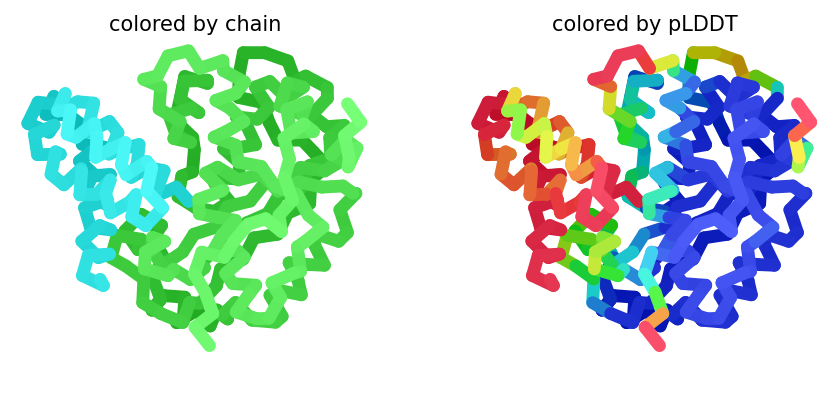

2026-05-08 01:28:24,435 alphafold2_multimer_v3_model_1_seed_001 recycle=0 pLDDT=76.9 pTM=0.796 ipTM=0.489
2026-05-08 01:28:29,021 alphafold2_multimer_v3_model_1_seed_001 recycle=1 pLDDT=76.3 pTM=0.776 ipTM=0.394 tol=0.804
2026-05-08 01:28:33,568 alphafold2_multimer_v3_model_1_seed_001 recycle=2 pLDDT=77.8 pTM=0.78 ipTM=0.394 tol=0.828
2026-05-08 01:28:38,201 alphafold2_multimer_v3_model_1_seed_001 recycle=3 pLDDT=81.1 pTM=0.777 ipTM=0.385 tol=0.764
2026-05-08 01:28:42,793 alphafold2_multimer_v3_model_1_seed_001 recycle=4 pLDDT=83.2 pTM=0.805 ipTM=0.485 tol=0.557
2026-05-08 01:28:47,410 alphafold2_multimer_v3_model_1_seed_001 recycle=5 pLDDT=86.5 pTM=0.841 ipTM=0.62 tol=0.455
2026-05-08 01:28:47,412 alphafold2_multimer_v3_model_1_seed_001 took 27.6s (5 recycles)


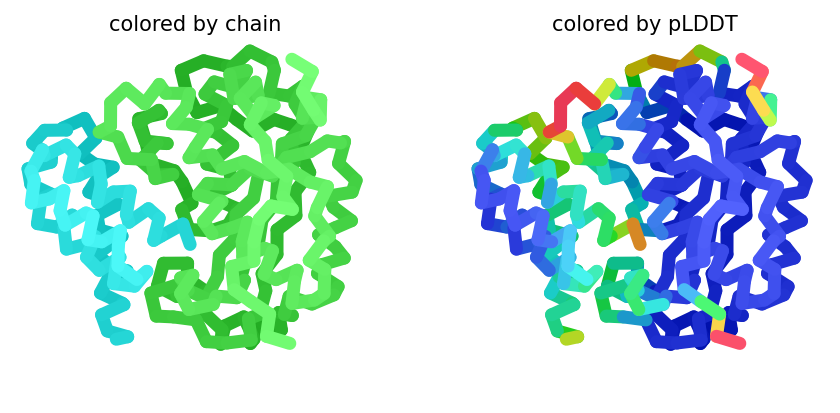

2026-05-08 01:28:52,209 alphafold2_multimer_v3_model_2_seed_001 recycle=0 pLDDT=77.1 pTM=0.771 ipTM=0.407
2026-05-08 01:28:56,828 alphafold2_multimer_v3_model_2_seed_001 recycle=1 pLDDT=81.8 pTM=0.815 ipTM=0.545 tol=1.73
2026-05-08 01:29:01,499 alphafold2_multimer_v3_model_2_seed_001 recycle=2 pLDDT=89.9 pTM=0.892 ipTM=0.814 tol=0.843
2026-05-08 01:29:06,187 alphafold2_multimer_v3_model_2_seed_001 recycle=3 pLDDT=88.9 pTM=0.875 ipTM=0.752 tol=0.335
2026-05-08 01:29:06,187 alphafold2_multimer_v3_model_2_seed_001 took 18.5s (3 recycles)


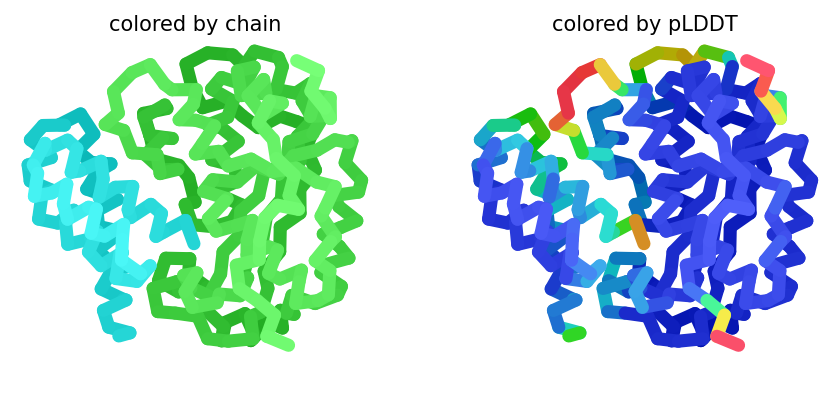

2026-05-08 01:29:11,085 alphafold2_multimer_v3_model_3_seed_001 recycle=0 pLDDT=74.6 pTM=0.742 ipTM=0.286
2026-05-08 01:29:15,665 alphafold2_multimer_v3_model_3_seed_001 recycle=1 pLDDT=80.3 pTM=0.78 ipTM=0.397 tol=2.6
2026-05-08 01:29:20,207 alphafold2_multimer_v3_model_3_seed_001 recycle=2 pLDDT=84.6 pTM=0.784 ipTM=0.406 tol=1.09
2026-05-08 01:29:24,821 alphafold2_multimer_v3_model_3_seed_001 recycle=3 pLDDT=84.8 pTM=0.8 ipTM=0.464 tol=0.326
2026-05-08 01:29:24,822 alphafold2_multimer_v3_model_3_seed_001 took 18.4s (3 recycles)


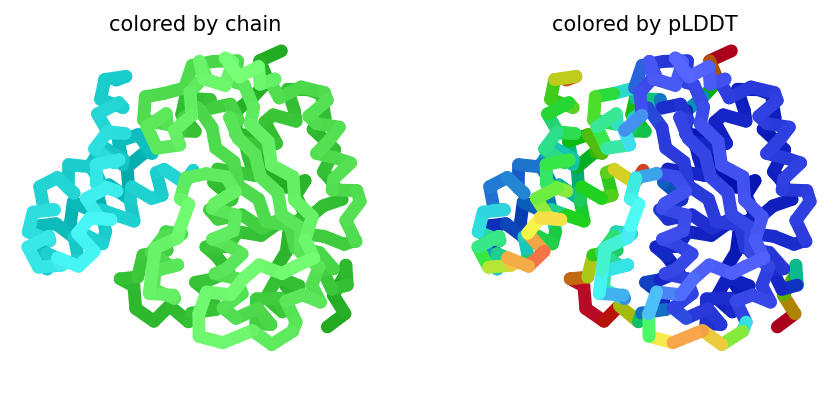

2026-05-08 01:29:29,682 alphafold2_multimer_v3_model_4_seed_001 recycle=0 pLDDT=79.2 pTM=0.823 ipTM=0.576
2026-05-08 01:29:34,291 alphafold2_multimer_v3_model_4_seed_001 recycle=1 pLDDT=79.7 pTM=0.803 ipTM=0.507 tol=1.02
2026-05-08 01:29:38,931 alphafold2_multimer_v3_model_4_seed_001 recycle=2 pLDDT=81.6 pTM=0.812 ipTM=0.528 tol=0.977
2026-05-08 01:29:43,525 alphafold2_multimer_v3_model_4_seed_001 recycle=3 pLDDT=86.2 pTM=0.854 ipTM=0.665 tol=1.07
2026-05-08 01:29:48,270 alphafold2_multimer_v3_model_4_seed_001 recycle=4 pLDDT=89.4 pTM=0.887 ipTM=0.784 tol=0.7
2026-05-08 01:29:52,799 alphafold2_multimer_v3_model_4_seed_001 recycle=5 pLDDT=90 pTM=0.89 ipTM=0.796 tol=0.198
2026-05-08 01:29:52,800 alphafold2_multimer_v3_model_4_seed_001 took 27.7s (5 recycles)


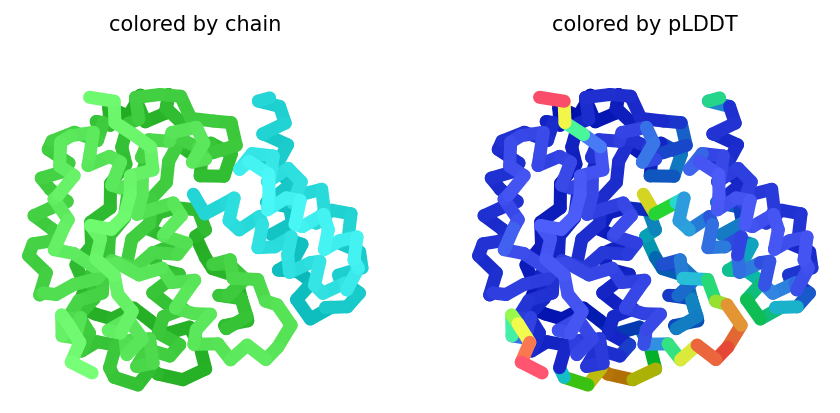

2026-05-08 01:29:57,667 alphafold2_multimer_v3_model_5_seed_001 recycle=0 pLDDT=74.4 pTM=0.75 ipTM=0.317
2026-05-08 01:30:02,305 alphafold2_multimer_v3_model_5_seed_001 recycle=1 pLDDT=76.3 pTM=0.766 ipTM=0.35 tol=1.26
2026-05-08 01:30:06,871 alphafold2_multimer_v3_model_5_seed_001 recycle=2 pLDDT=76.9 pTM=0.766 ipTM=0.355 tol=0.8
2026-05-08 01:30:11,507 alphafold2_multimer_v3_model_5_seed_001 recycle=3 pLDDT=76.6 pTM=0.758 ipTM=0.316 tol=1.59
2026-05-08 01:30:16,271 alphafold2_multimer_v3_model_5_seed_001 recycle=4 pLDDT=75.2 pTM=0.759 ipTM=0.325 tol=1.26
2026-05-08 01:30:20,871 alphafold2_multimer_v3_model_5_seed_001 recycle=5 pLDDT=75.7 pTM=0.768 ipTM=0.355 tol=0.674
2026-05-08 01:30:25,484 alphafold2_multimer_v3_model_5_seed_001 recycle=6 pLDDT=76.9 pTM=0.77 ipTM=0.365 tol=0.751
2026-05-08 01:30:30,273 alphafold2_multimer_v3_model_5_seed_001 recycle=7 pLDDT=75.8 pTM=0.762 ipTM=0.325 tol=0.9
2026-05-08 01:30:34,883 alphafold2_multimer_v3_model_5_seed_001 recycle=8 pLDDT=75.2 pTM=0.7

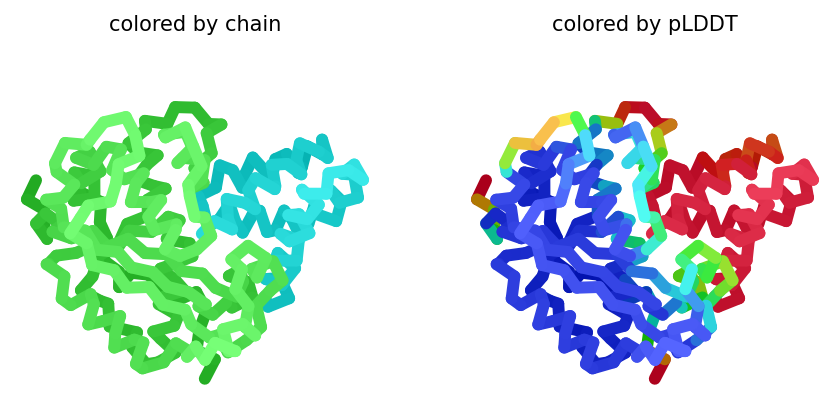

2026-05-08 01:30:44,252 alphafold2_multimer_v3_model_1_seed_002 recycle=0 pLDDT=79.2 pTM=0.814 ipTM=0.549
2026-05-08 01:30:48,883 alphafold2_multimer_v3_model_1_seed_002 recycle=1 pLDDT=85.3 pTM=0.865 ipTM=0.718 tol=1.58
2026-05-08 01:30:53,479 alphafold2_multimer_v3_model_1_seed_002 recycle=2 pLDDT=89.5 pTM=0.889 ipTM=0.806 tol=0.563
2026-05-08 01:30:58,273 alphafold2_multimer_v3_model_1_seed_002 recycle=3 pLDDT=89.9 pTM=0.894 ipTM=0.819 tol=0.587
2026-05-08 01:31:02,918 alphafold2_multimer_v3_model_1_seed_002 recycle=4 pLDDT=90.1 pTM=0.892 ipTM=0.813 tol=0.348
2026-05-08 01:31:02,919 alphafold2_multimer_v3_model_1_seed_002 took 23.2s (4 recycles)


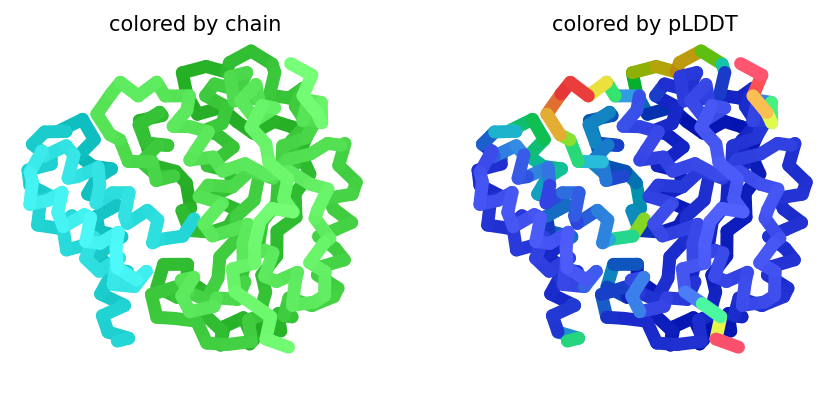

2026-05-08 01:31:07,714 alphafold2_multimer_v3_model_2_seed_002 recycle=0 pLDDT=76.7 pTM=0.769 ipTM=0.407
2026-05-08 01:31:12,335 alphafold2_multimer_v3_model_2_seed_002 recycle=1 pLDDT=84.2 pTM=0.854 ipTM=0.675 tol=1.87
2026-05-08 01:31:16,955 alphafold2_multimer_v3_model_2_seed_002 recycle=2 pLDDT=87.2 pTM=0.853 ipTM=0.677 tol=0.872
2026-05-08 01:31:21,564 alphafold2_multimer_v3_model_2_seed_002 recycle=3 pLDDT=88.6 pTM=0.872 ipTM=0.741 tol=0.271
2026-05-08 01:31:21,564 alphafold2_multimer_v3_model_2_seed_002 took 18.4s (3 recycles)


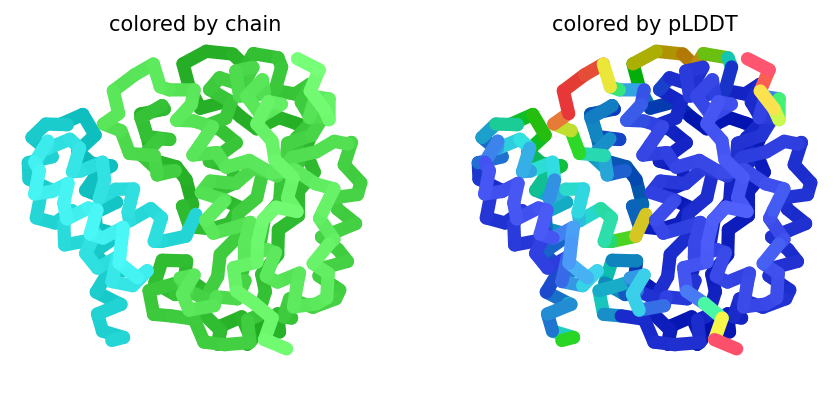

2026-05-08 01:31:26,416 alphafold2_multimer_v3_model_3_seed_002 recycle=0 pLDDT=74.5 pTM=0.74 ipTM=0.281
2026-05-08 01:31:31,029 alphafold2_multimer_v3_model_3_seed_002 recycle=1 pLDDT=80 pTM=0.783 ipTM=0.412 tol=2.78
2026-05-08 01:31:35,812 alphafold2_multimer_v3_model_3_seed_002 recycle=2 pLDDT=84.2 pTM=0.784 ipTM=0.417 tol=1.08
2026-05-08 01:31:40,352 alphafold2_multimer_v3_model_3_seed_002 recycle=3 pLDDT=85.4 pTM=0.816 ipTM=0.531 tol=0.751
2026-05-08 01:31:44,976 alphafold2_multimer_v3_model_3_seed_002 recycle=4 pLDDT=85.7 pTM=0.814 ipTM=0.518 tol=0.255
2026-05-08 01:31:44,976 alphafold2_multimer_v3_model_3_seed_002 took 23.2s (4 recycles)


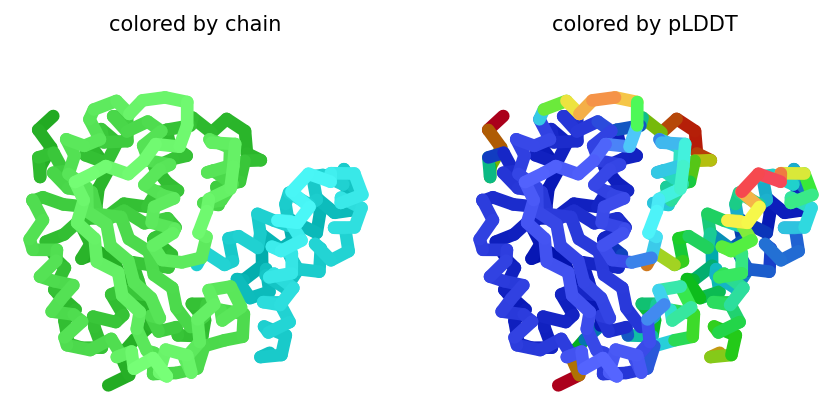

2026-05-08 01:31:49,854 alphafold2_multimer_v3_model_4_seed_002 recycle=0 pLDDT=78.1 pTM=0.801 ipTM=0.502
2026-05-08 01:31:54,434 alphafold2_multimer_v3_model_4_seed_002 recycle=1 pLDDT=78.6 pTM=0.789 ipTM=0.44 tol=1
2026-05-08 01:31:59,007 alphafold2_multimer_v3_model_4_seed_002 recycle=2 pLDDT=79.9 pTM=0.787 ipTM=0.428 tol=0.84
2026-05-08 01:32:03,634 alphafold2_multimer_v3_model_4_seed_002 recycle=3 pLDDT=82.6 pTM=0.792 ipTM=0.443 tol=1.05
2026-05-08 01:32:08,212 alphafold2_multimer_v3_model_4_seed_002 recycle=4 pLDDT=86.1 pTM=0.834 ipTM=0.597 tol=0.558
2026-05-08 01:32:13,019 alphafold2_multimer_v3_model_4_seed_002 recycle=5 pLDDT=88.5 pTM=0.867 ipTM=0.704 tol=0.227
2026-05-08 01:32:13,020 alphafold2_multimer_v3_model_4_seed_002 took 27.8s (5 recycles)


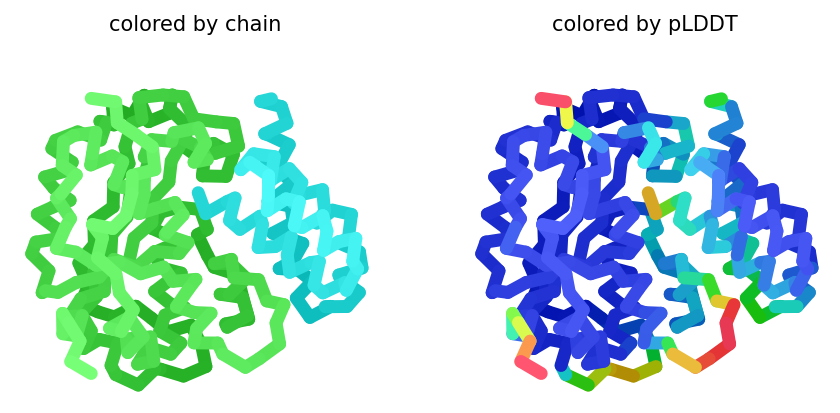

2026-05-08 01:32:17,939 alphafold2_multimer_v3_model_5_seed_002 recycle=0 pLDDT=74.8 pTM=0.756 ipTM=0.338
2026-05-08 01:32:22,536 alphafold2_multimer_v3_model_5_seed_002 recycle=1 pLDDT=76.7 pTM=0.77 ipTM=0.362 tol=1.45
2026-05-08 01:32:27,155 alphafold2_multimer_v3_model_5_seed_002 recycle=2 pLDDT=78 pTM=0.77 ipTM=0.358 tol=1.05
2026-05-08 01:32:31,715 alphafold2_multimer_v3_model_5_seed_002 recycle=3 pLDDT=77.9 pTM=0.761 ipTM=0.325 tol=1.95
2026-05-08 01:32:36,342 alphafold2_multimer_v3_model_5_seed_002 recycle=4 pLDDT=77.1 pTM=0.758 ipTM=0.311 tol=1.21
2026-05-08 01:32:41,087 alphafold2_multimer_v3_model_5_seed_002 recycle=5 pLDDT=77.6 pTM=0.758 ipTM=0.309 tol=0.739
2026-05-08 01:32:45,759 alphafold2_multimer_v3_model_5_seed_002 recycle=6 pLDDT=77 pTM=0.757 ipTM=0.297 tol=1.78
2026-05-08 01:32:50,385 alphafold2_multimer_v3_model_5_seed_002 recycle=7 pLDDT=76.4 pTM=0.761 ipTM=0.318 tol=1.22
2026-05-08 01:32:55,129 alphafold2_multimer_v3_model_5_seed_002 recycle=8 pLDDT=78.5 pTM=0.76 

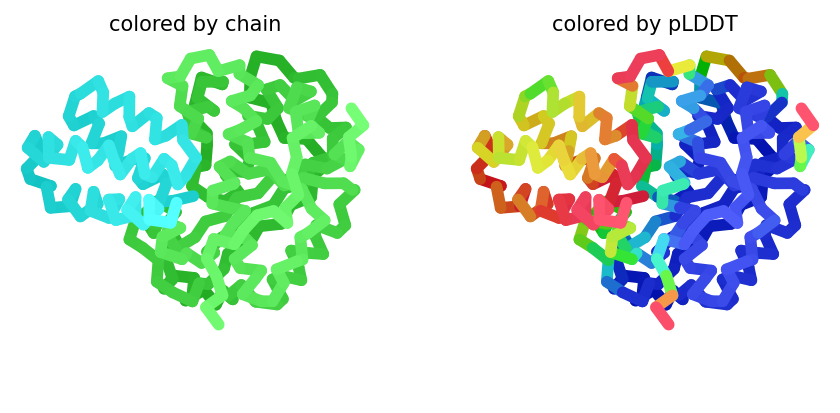

2026-05-08 01:33:04,607 alphafold2_multimer_v3_model_1_seed_003 recycle=0 pLDDT=79.3 pTM=0.803 ipTM=0.515
2026-05-08 01:33:09,208 alphafold2_multimer_v3_model_1_seed_003 recycle=1 pLDDT=89.1 pTM=0.895 ipTM=0.834 tol=1.54
2026-05-08 01:33:13,853 alphafold2_multimer_v3_model_1_seed_003 recycle=2 pLDDT=89.8 pTM=0.893 ipTM=0.82 tol=0.498
2026-05-08 01:33:13,854 alphafold2_multimer_v3_model_1_seed_003 took 13.9s (2 recycles)


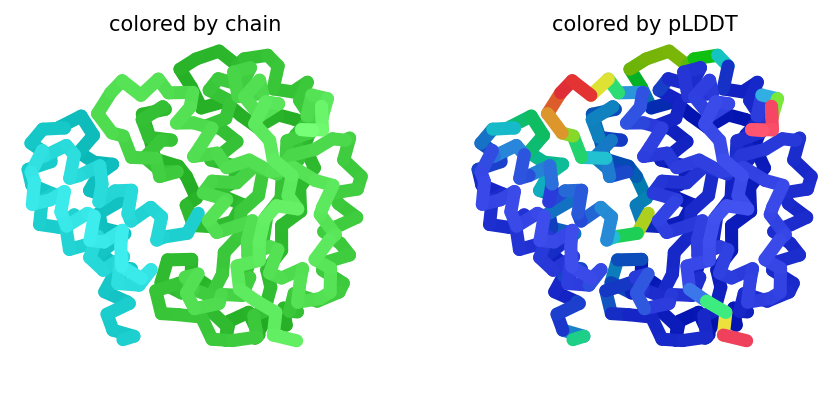

2026-05-08 01:33:18,675 alphafold2_multimer_v3_model_2_seed_003 recycle=0 pLDDT=76.7 pTM=0.768 ipTM=0.399
2026-05-08 01:33:23,334 alphafold2_multimer_v3_model_2_seed_003 recycle=1 pLDDT=84.8 pTM=0.858 ipTM=0.683 tol=1.73
2026-05-08 01:33:27,941 alphafold2_multimer_v3_model_2_seed_003 recycle=2 pLDDT=86 pTM=0.839 ipTM=0.636 tol=0.964
2026-05-08 01:33:32,678 alphafold2_multimer_v3_model_2_seed_003 recycle=3 pLDDT=88.1 pTM=0.868 ipTM=0.731 tol=0.613
2026-05-08 01:33:37,266 alphafold2_multimer_v3_model_2_seed_003 recycle=4 pLDDT=88.5 pTM=0.869 ipTM=0.729 tol=0.232
2026-05-08 01:33:37,267 alphafold2_multimer_v3_model_2_seed_003 took 23.2s (4 recycles)


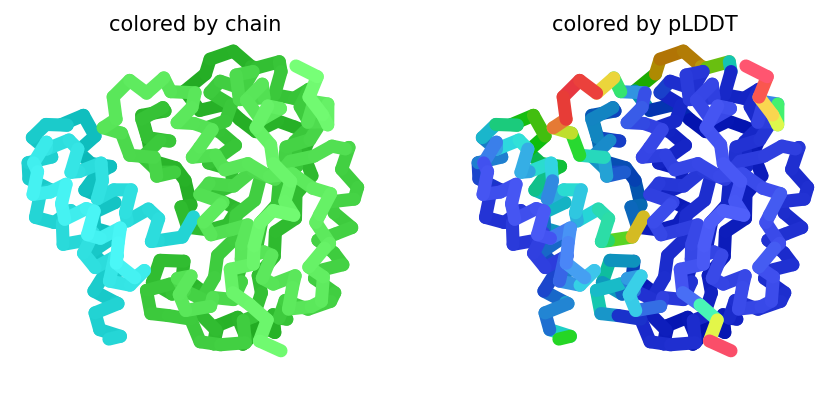

2026-05-08 01:33:42,156 alphafold2_multimer_v3_model_3_seed_003 recycle=0 pLDDT=75.5 pTM=0.742 ipTM=0.279
2026-05-08 01:33:46,770 alphafold2_multimer_v3_model_3_seed_003 recycle=1 pLDDT=79.7 pTM=0.777 ipTM=0.382 tol=1.79
2026-05-08 01:33:51,365 alphafold2_multimer_v3_model_3_seed_003 recycle=2 pLDDT=84.8 pTM=0.789 ipTM=0.43 tol=1.11
2026-05-08 01:33:55,916 alphafold2_multimer_v3_model_3_seed_003 recycle=3 pLDDT=86.2 pTM=0.826 ipTM=0.561 tol=0.539
2026-05-08 01:34:00,512 alphafold2_multimer_v3_model_3_seed_003 recycle=4 pLDDT=85.4 pTM=0.806 ipTM=0.484 tol=0.204
2026-05-08 01:34:00,513 alphafold2_multimer_v3_model_3_seed_003 took 23.0s (4 recycles)


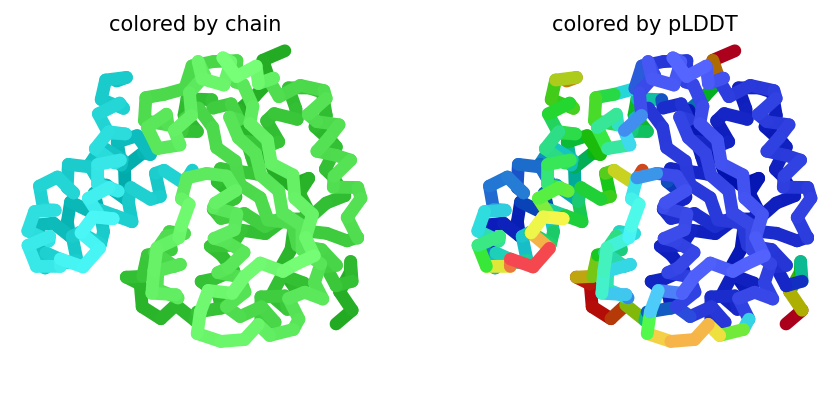

2026-05-08 01:34:05,366 alphafold2_multimer_v3_model_4_seed_003 recycle=0 pLDDT=78.6 pTM=0.811 ipTM=0.534
2026-05-08 01:34:09,993 alphafold2_multimer_v3_model_4_seed_003 recycle=1 pLDDT=78.8 pTM=0.788 ipTM=0.445 tol=1.34
2026-05-08 01:34:14,746 alphafold2_multimer_v3_model_4_seed_003 recycle=2 pLDDT=81.9 pTM=0.814 ipTM=0.536 tol=0.879
2026-05-08 01:34:19,351 alphafold2_multimer_v3_model_4_seed_003 recycle=3 pLDDT=89.6 pTM=0.896 ipTM=0.822 tol=1.37
2026-05-08 01:34:24,025 alphafold2_multimer_v3_model_4_seed_003 recycle=4 pLDDT=89.7 pTM=0.891 ipTM=0.805 tol=0.35
2026-05-08 01:34:24,027 alphafold2_multimer_v3_model_4_seed_003 took 23.3s (4 recycles)


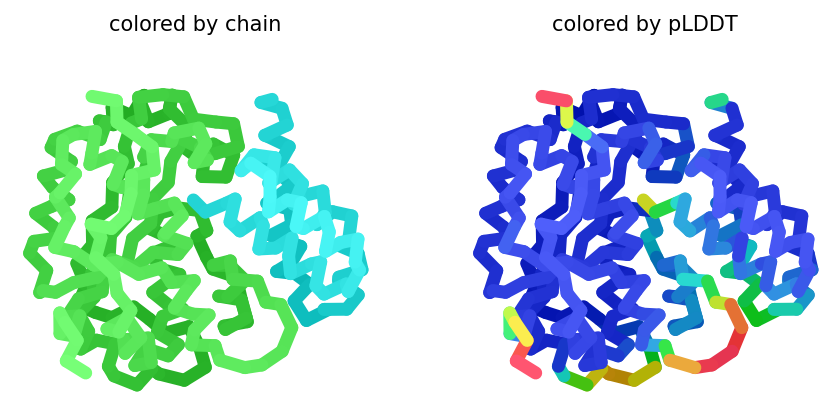

2026-05-08 01:34:28,920 alphafold2_multimer_v3_model_5_seed_003 recycle=0 pLDDT=74.6 pTM=0.748 ipTM=0.304
2026-05-08 01:34:33,515 alphafold2_multimer_v3_model_5_seed_003 recycle=1 pLDDT=75.6 pTM=0.764 ipTM=0.339 tol=2.4
2026-05-08 01:34:38,272 alphafold2_multimer_v3_model_5_seed_003 recycle=2 pLDDT=74.8 pTM=0.758 ipTM=0.331 tol=0.801
2026-05-08 01:34:42,833 alphafold2_multimer_v3_model_5_seed_003 recycle=3 pLDDT=75 pTM=0.761 ipTM=0.329 tol=1.13
2026-05-08 01:34:47,360 alphafold2_multimer_v3_model_5_seed_003 recycle=4 pLDDT=75.6 pTM=0.762 ipTM=0.332 tol=0.434
2026-05-08 01:34:47,361 alphafold2_multimer_v3_model_5_seed_003 took 23.1s (4 recycles)


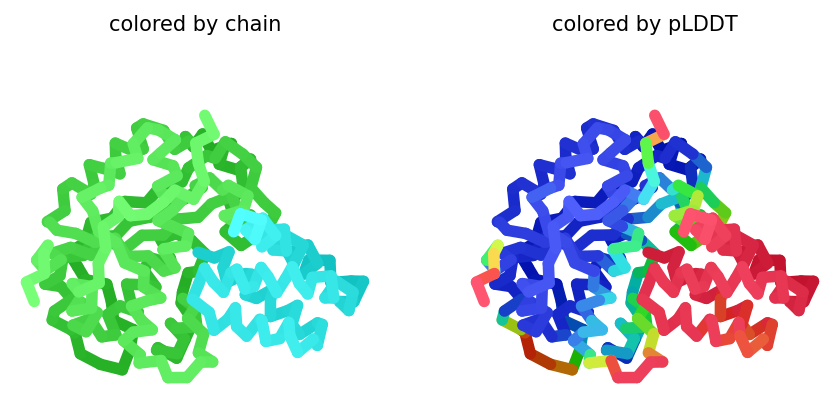

2026-05-08 01:34:47,590 reranking models by 'multimer' metric
2026-05-08 01:34:47,590 rank_001_alphafold2_multimer_v3_model_1_seed_003 pLDDT=89.8 pTM=0.893 ipTM=0.82
2026-05-08 01:34:47,593 rank_002_alphafold2_multimer_v3_model_1_seed_000 pLDDT=89.9 pTM=0.894 ipTM=0.817
2026-05-08 01:34:47,595 rank_003_alphafold2_multimer_v3_model_1_seed_002 pLDDT=90.1 pTM=0.892 ipTM=0.813
2026-05-08 01:34:47,596 rank_004_alphafold2_multimer_v3_model_4_seed_000 pLDDT=90 pTM=0.893 ipTM=0.805
2026-05-08 01:34:47,598 rank_005_alphafold2_multimer_v3_model_4_seed_003 pLDDT=89.7 pTM=0.891 ipTM=0.805
2026-05-08 01:34:47,600 rank_006_alphafold2_multimer_v3_model_4_seed_001 pLDDT=90 pTM=0.89 ipTM=0.796
2026-05-08 01:34:47,602 rank_007_alphafold2_multimer_v3_model_2_seed_001 pLDDT=88.9 pTM=0.875 ipTM=0.752
2026-05-08 01:34:47,603 rank_008_alphafold2_multimer_v3_model_2_seed_002 pLDDT=88.6 pTM=0.872 ipTM=0.741
2026-05-08 01:34:47,605 rank_009_alphafold2_multimer_v3_model_2_seed_003 pLDDT=88.5 pTM=0.869 ipTM=0.729

In [24]:
# Run prediction: remote MSA/template lookup, local GPU inference.
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from Bio import BiopythonDeprecationWarning
from colabfold.batch import get_queries, run, set_model_type
from colabfold.colabfold import plot_protein
from colabfold.download import download_alphafold_params
from colabfold.plot import plot_msa_v2
from colabfold.utils import setup_logging

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=BiopythonDeprecationWarning)

def _parse_optional_int(value):
    return None if value == "auto" else int(value)

def _input_features_callback(input_features):
    if display_images.value:
        plot_msa_v2(input_features)
        plt.show()
        plt.close()

def _prediction_callback(protein_obj, length, prediction_result, input_features, mode):
    model_name, relaxed = mode
    if display_images.value and not relaxed:
        fig = plot_protein(protein_obj, Ls=length, dpi=150)
        plt.show()
        plt.close()

log_filename = job_dir / "log.txt"
setup_logging(log_filename)

queries, is_complex = get_queries(str(queries_path))
selected_model_type = set_model_type(is_complex, model_type.value)
selected_num_recycles = _parse_optional_int(num_recycles.value)
selected_max_msa = None if max_msa.value == "auto" else max_msa.value
use_cluster_profile = not ("multimer" in selected_model_type and selected_max_msa is not None)

print("Queries:", len(queries))
print("Complex input:", is_complex)
print("Model type:", selected_model_type)
print("MSA mode:", selected_msa_mode)
print("Host URL:", HOST_URL)
print("Downloading/checking AlphaFold parameters if needed...")
download_alphafold_params(selected_model_type, Path("."))

results = run(
    queries=queries,
    result_dir=job_dir,
    use_templates=use_templates,
    custom_template_path=str(resolved_custom_template_path) if resolved_custom_template_path else None,
    num_relax=num_relax.value,
    msa_mode=selected_msa_mode,
    model_type=selected_model_type,
    num_models=5,
    num_recycles=selected_num_recycles,
    relax_max_iterations=relax_max_iterations.value,
    recycle_early_stop_tolerance=None,
    num_seeds=num_seeds.value,
    use_dropout=use_dropout.value,
    model_order=[1, 2, 3, 4, 5],
    is_complex=is_complex,
    data_dir=Path("."),
    keep_existing_results=False,
    rank_by="auto",
    pair_mode=pair_mode.value,
    pairing_strategy=pairing_strategy.value,
    stop_at_score=100,
    prediction_callback=_prediction_callback,
    dpi=200,
    zip_results=False,
    save_all=save_all.value,
    max_msa=selected_max_msa,
    use_cluster_profile=use_cluster_profile,
    input_features_callback=_input_features_callback,
    save_recycles=save_recycles.value,
    host_url=HOST_URL,
    user_agent="colabfold/local-notebook",
    calc_extra_ptm=False,
)

print("Prediction finished:", job_dir)

In [25]:
# Package results.
import shutil

if zip_results.value:
    archive_base = job_dir.parent / f"{job_dir.name}.result"
    archive_path = shutil.make_archive(str(archive_base), "zip", root_dir=job_dir.parent, base_dir=job_dir.name)
    print("Result zip:", archive_path)
else:
    print("Results directory:", job_dir)

Results directory: /export/data/sfan/ColabFold/outputs/TREX1/TREX1_top_13_8f32d


In [26]:
# Optional structure viewer for the top-ranked PDB.
import glob
import py3Dmol

ranked_pdbs = sorted(glob.glob(str(job_dir / "*rank_001*.pdb")))
if not ranked_pdbs:
    ranked_pdbs = sorted(glob.glob(str(job_dir / "*.pdb")))

if ranked_pdbs:
    pdb_path = ranked_pdbs[0]
    view = py3Dmol.view(width=900, height=600, js="https://3dmol.org/build/3Dmol.js")
    view.addModel(Path(pdb_path).read_text(), "pdb")
    view.setStyle({"cartoon": {"color": "spectrum"}})
    view.zoomTo()
    print("Viewing:", pdb_path)
    view.show()
else:
    print("No PDB files found yet. Run prediction first.")

Viewing: /export/data/sfan/ColabFold/outputs/TREX1/TREX1_top_13_8f32d/TREX1_top_13_8f32d_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_003.pdb


3Dmol.js failed to load for some reason. Please check your browser console for error messages.